<a href="https://colab.research.google.com/github/Group-k-project/final-project/blob/main/K_group.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scipy.sparse as sp
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, accuracy_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier
SEED = 42
TARGET, ID = 'h1n1_vaccine', 'respondent_id'
pd.set_option('display.max_columns', None)

In [28]:
# Load the data

In [29]:
train  = pd.read_csv('dataset_B_training.csv')
test   = pd.read_csv('dataset_B_testing.csv')
sample = pd.read_csv('/content/dataset_B_training.csv')
print('train:', train.shape, '  test:', test.shape)
train.head()

train: (4756, 31)   test: (4749, 30)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,h1n1_vaccine
0,1,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,4.0,4.0,1.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",2.0,1.0,science,0
1,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,1.0,2.0,18 - 34 Years,Some College,White,Female,Below Poverty,Not Married,Own,Employed,Non-MSA,0.0,3.0,wholesale,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,NaN,0.0,0.0,0.0,1.0,3.0,4.0,2.0,45 - 54 Years,College Graduate,White,Female,"> $75,000",Not Married,Own,Employed,"MSA, Principle City",0.0,0.0,education,1
3,4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,4.0,18 - 34 Years,College Graduate,White,Female,"<= $75,000, Above Poverty",Not Married,Rent,Not in Labor Force,Non-MSA,0.0,0.0,NaN,0
4,5,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,2.0,2.0,1.0,18 - 34 Years,< 12 Years,White,Female,NaN,Not Married,NaN,Unemployed,Non-MSA,3.0,0.0,NaN,0


h1n1_vaccine
0    2882
1    1874
Name: count, dtype: int64
share vaccinated: 0.394


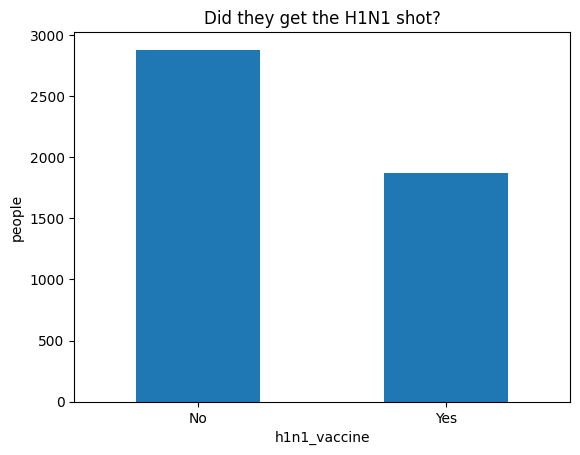

In [37]:
print(train[TARGET].value_counts()); print('share vaccinated: %.3f' % train[TARGET].mean())
train[TARGET].value_counts().sort_index().plot(kind='bar', title='Did they get the H1N1 shot?')
plt.xticks([0,1], ['No','Yes'], rotation=0); plt.ylabel('people'); plt.show()

employment_sector              49.7
health_insurance               40.5
income_poverty                 15.0
doctor_recc_h1n1                6.7
rent_or_own                     6.6
employment_status               4.9
marital_status                  4.8
education                       4.7
chronic_med_condition           3.4
health_worker                   2.8
child_under_6_months            2.8
opinion_h1n1_vacc_effective     1.5
opinion_h1n1_sick_from_vacc     1.3
opinion_h1n1_risk               1.3
household_adults                0.7
household_children              0.7
behavioral_avoidance            0.6
h1n1_knowledge                  0.5
behavioral_antiviral_meds       0.4
behavioral_touch_face           0.4
h1n1_concern                    0.3
behavioral_outside_home         0.3
behavioral_large_gatherings     0.2
behavioral_wash_hands           0.2
behavioral_face_mask            0.1
dtype: float64


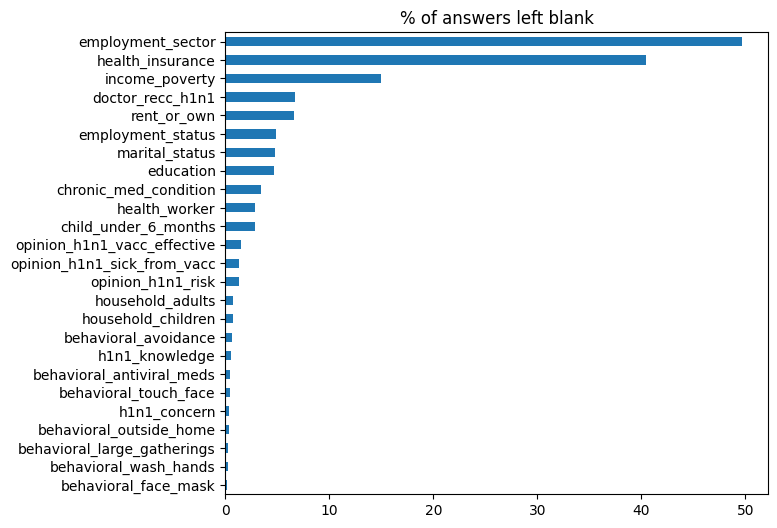

In [30]:
gaps = (train.isna().mean()*100).round(1); gaps = gaps[gaps>0].sort_values(ascending=False)
print(gaps)
gaps.plot(kind='barh', figsize=(7,6), title='% of answers left blank'); plt.gca().invert_yaxis(); plt.show()

doctor_recc_h1n1               0.413874
opinion_h1n1_risk              0.362183
opinion_h1n1_vacc_effective    0.325057
health_worker                  0.205428
h1n1_knowledge                 0.148766
h1n1_concern                   0.143235
health_insurance               0.129246
chronic_med_condition          0.107138
behavioral_touch_face          0.103222
behavioral_wash_hands          0.092827
Name: h1n1_vaccine, dtype: float64


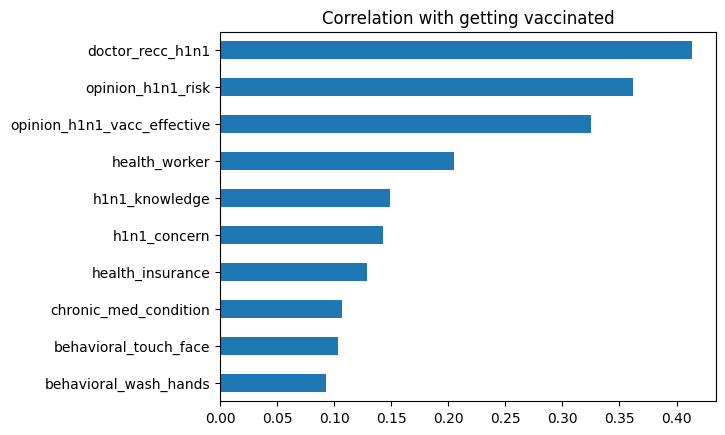

In [31]:
numeric = train.select_dtypes('number').drop(columns=[ID])
signal = numeric.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print(signal.head(10))
signal.head(10).plot(kind='barh', title='Correlation with getting vaccinated'); plt.gca().invert_yaxis(); plt.show()

In [32]:
y = train[TARGET].values
X = train.drop(columns=[TARGET, ID]).copy(); X_test = test.drop(columns=[ID]).copy()
text_cols = ['age_group','education','race','sex','income_poverty','marital_status',
             'rent_or_own','employment_status','census_msa','employment_sector']
target_enc_cols = ['employment_sector']
onehot_cols = [c for c in text_cols if c not in target_enc_cols]
base_num    = [c for c in X.columns if c not in text_cols]
for df in (X, X_test):
    for c in text_cols: df[c] = df[c].fillna('Missing').astype(str)
precautions = ['behavioral_antiviral_meds','behavioral_avoidance','behavioral_face_mask','behavioral_wash_hands',
               'behavioral_large_gatherings','behavioral_outside_home','behavioral_touch_face']
for df in (X, X_test):
    df['behavioral_count'] = df[precautions].sum(axis=1)
    df['doc_x_risk'] = df['doctor_recc_h1n1'].fillna(0) * df['opinion_h1n1_risk'].fillna(0)
eng_num = ['behavioral_count','doc_x_risk']
print('one-hot text:', len(onehot_cols), ' target-encoded:', target_enc_cols)

one-hot text: 9  target-encoded: ['employment_sector']


In [26]:
def encode_sector(fit_values, fit_labels, apply_values, m=20.0):
    overall = fit_labels.mean()
    tbl = pd.DataFrame({'sector': fit_values.values, 'y': fit_labels})
    stats = tbl.groupby('sector')['y'].agg(['mean','count'])
    smoothed = (stats['mean']*stats['count'] + overall*m) / (stats['count'] + m)
    return apply_values.map(smoothed).fillna(overall).values

In [25]:
num_cols = base_num + eng_num + ['emp_sector_te']
def make_preprocessor(impute, scale):
    steps = []
    if impute: steps.append(('impute', SimpleImputer(strategy='median')))
    if scale:  steps.append(('scale', StandardScaler()))
    numeric = Pipeline(steps) if steps else 'passthrough'
    return ColumnTransformer([('num', numeric, num_cols),
                              ('cat', OneHotEncoder(handle_unknown='ignore'), onehot_cols)])

def logreg():       return Pipeline([('prep', make_preprocessor(True, True)),
                                     ('model', LogisticRegression(max_iter=3000, C=0.5))])
def random_forest():return Pipeline([('prep', make_preprocessor(True, False)),
                                     ('model', RandomForestClassifier(n_estimators=600, min_samples_leaf=5,
                                               max_features='sqrt', n_jobs=-1, random_state=SEED))])
def hist_gbm():     return Pipeline([('prep', make_preprocessor(False, False)),
                                     ('model', HistGradientBoostingClassifier(learning_rate=0.03, max_iter=800,
                                               max_leaf_nodes=31, min_samples_leaf=40, l2_regularization=2.0,
                                               early_stopping=True, validation_fraction=0.1, random_state=SEED))])
def light_gbm():    return Pipeline([('prep', make_preprocessor(False, False)),
                                     ('model', LGBMClassifier(n_estimators=700, learning_rate=0.02, num_leaves=31,
                                               min_child_samples=40, subsample=0.8, subsample_freq=1,
                                               colsample_bytree=0.8, reg_lambda=2.0, random_state=SEED, verbose=-1))])
model_builders = {'LogReg': logreg, 'RandomForest': random_forest,
                  'HistGBM': hist_gbm, 'LightGBM': light_gbm}

In [23]:
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof  = {n: np.zeros(len(X))      for n in model_builders}
test_pred = {n: np.zeros(len(X_test)) for n in model_builders}
for tr_idx, va_idx in folds.split(X, y):
    X_tr, X_val, X_te = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy(), X_test.copy()
    X_tr['emp_sector_te']  = encode_sector(X_tr['employment_sector'], y[tr_idx], X_tr['employment_sector'])
    X_val['emp_sector_te'] = encode_sector(X_tr['employment_sector'], y[tr_idx], X_val['employment_sector'])
    X_te['emp_sector_te']  = encode_sector(X_tr['employment_sector'], y[tr_idx], X_te['employment_sector'])
    for n, build in model_builders.items():
        m = build(); m.fit(X_tr, y[tr_idx])
        oof[n][va_idx] += m.predict_proba(X_val)[:,1]
        test_pred[n]   += m.predict_proba(X_te)[:,1] / folds.n_splits
print('=== held-out ROC-AUC per base model ===')
for n in model_builders: print(f'  {n:13s} {roc_auc_score(y, oof[n]):.4f}')

=== held-out ROC-AUC per base model ===
  LogReg        0.8221
  RandomForest  0.8252
  HistGBM       0.8511
  LightGBM      0.8510


In [24]:
names = list(model_builders); best_auc, best_w = -1, None; grid = np.arange(0, 1.0001, 0.1)
for a in grid:
    for b in grid:
        for cc in grid:
            d = 1 - a - b - cc
            if d < -1e-9: continue
            p = a*oof['LogReg'] + b*oof['RandomForest'] + cc*oof['HistGBM'] + d*oof['LightGBM']
            au = roc_auc_score(y, p)
            if au > best_auc: best_auc, best_w = au, (round(a,2), round(b,2), round(cc,2), round(d,2))
w = dict(zip(names, best_w))
oof['Ensemble']       = sum(w[n]*oof[n]       for n in names)
test_pred['Ensemble'] = sum(w[n]*test_pred[n] for n in names)
print('weights', w); print('Ensemble held-out ROC-AUC = %.4f' % best_auc)

weights {'LogReg': np.float64(0.1), 'RandomForest': np.float64(0.1), 'HistGBM': np.float64(0.4), 'LightGBM': np.float64(0.4)}
Ensemble held-out ROC-AUC = 0.8546


ROC-AUC : 0.8546
Accuracy: 0.7889
              precision    recall  f1-score   support

     no shot      0.802     0.866     0.832      2882
        shot      0.765     0.671     0.715      1874

    accuracy                          0.789      4756
   macro avg      0.783     0.768     0.774      4756
weighted avg      0.787     0.789     0.786      4756



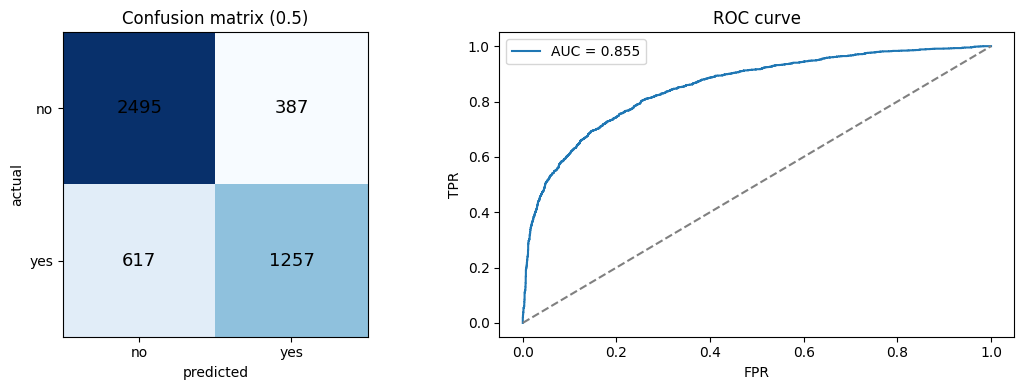

In [38]:
pred = (oof['Ensemble'] >= 0.5).astype(int)
print('ROC-AUC : %.4f' % roc_auc_score(y, oof['Ensemble']))
print('Accuracy: %.4f' % accuracy_score(y, pred))
print(classification_report(y, pred, target_names=['no shot','shot'], digits=3))
cm = confusion_matrix(y, pred)
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].imshow(cm, cmap='Blues'); ax[0].set_title('Confusion matrix (0.5)')
ax[0].set_xlabel('predicted'); ax[0].set_ylabel('actual')
ax[0].set_xticks([0,1]); ax[0].set_yticks([0,1]); ax[0].set_xticklabels(['no','yes']); ax[0].set_yticklabels(['no','yes'])
for i in range(2):
    for j in range(2): ax[0].text(j, i, cm[i,j], ha='center', va='center', fontsize=13)
fpr, tpr, _ = roc_curve(y, oof['Ensemble'])
ax[1].plot(fpr, tpr, label='AUC = %.3f' % roc_auc_score(y, oof['Ensemble'])); ax[1].plot([0,1],[0,1],'--',c='grey')
ax[1].set_title('ROC curve'); ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].legend()
plt.tight_layout(); plt.show()

       model  ROC-AUC  Accuracy  Precision  Recall     F1
    Ensemble   0.8546    0.7889     0.7646  0.6708 0.7146
     HistGBM   0.8511    0.7876     0.7631  0.6686 0.7127
    LightGBM   0.8510    0.7876     0.7599  0.6740 0.7144
RandomForest   0.8252    0.7662     0.7540  0.6035 0.6704
      LogReg   0.8221    0.7704     0.7441  0.6361 0.6858


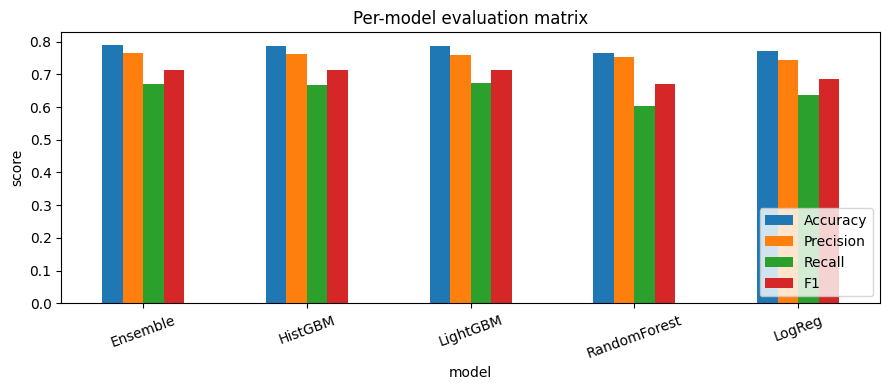

,model,ROC-AUC,Accuracy,Precision,Recall,F1
0,Ensemble,0.8546,0.7889,0.7646,0.6708,0.7146
1,HistGBM,0.8511,0.7876,0.7631,0.6686,0.7127
2,LightGBM,0.8510,0.7876,0.7599,0.6740,0.7144
3,RandomForest,0.8252,0.7662,0.7540,0.6035,0.6704
4,LogReg,0.8221,0.7704,0.7441,0.6361,0.6858


In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# evaluate every model on its leak-free out-of-fold predictions (threshold 0.5)
rows=[]
for name in oof:
    p=(oof[name]>=0.5).astype(int)
    rows.append({'model':name,
                 'ROC-AUC':round(roc_auc_score(y,oof[name]),4),
                 'Accuracy':round(accuracy_score(y,p),4),
                 'Precision':round(precision_score(y,p),4),
                 'Recall':round(recall_score(y,p),4),
                 'F1':round(f1_score(y,p),4)})
eval_matrix=pd.DataFrame(rows).sort_values('ROC-AUC',ascending=False).reset_index(drop=True)
print(eval_matrix.to_string(index=False))
eval_matrix.set_index('model')[['Accuracy','Precision','Recall','F1']].plot(kind='bar',figsize=(9,4))
plt.title('Per-model evaluation matrix'); plt.ylabel('score'); plt.xticks(rotation=20); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
eval_matrix

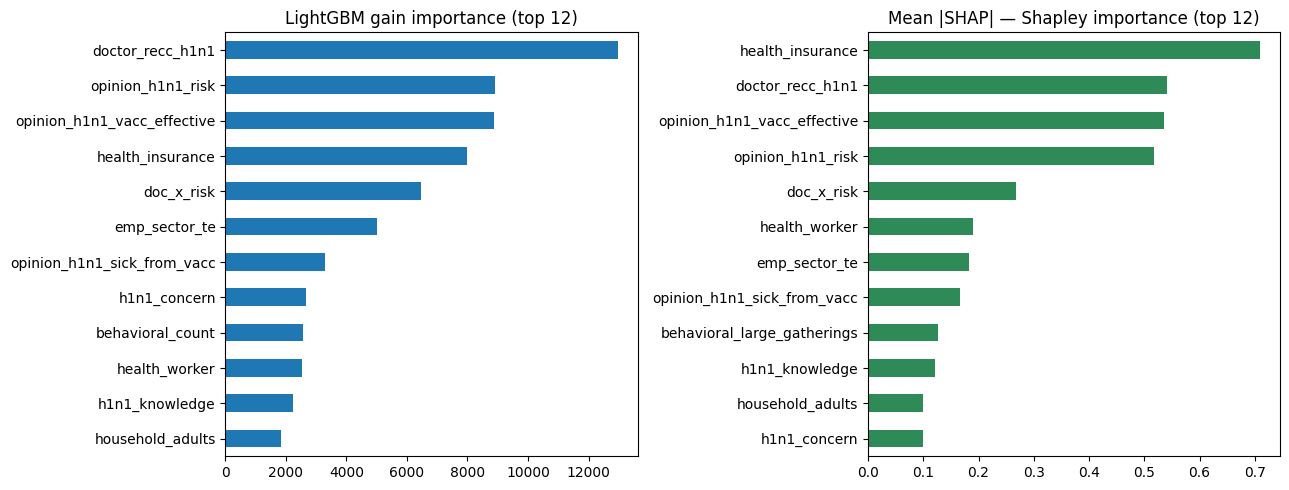

Top 6 by SHAP:
health_insurance               0.710
doctor_recc_h1n1               0.541
opinion_h1n1_vacc_effective    0.536
opinion_h1n1_risk              0.517
doc_x_risk                     0.267
health_worker                  0.191
dtype: float64


In [45]:
X_full = X.copy(); X_full['emp_sector_te'] = encode_sector(X_full['employment_sector'], y, X_full['employment_sector'])
lgb = light_gbm(); lgb.fit(X_full, y)
ohe = lgb.named_steps['prep'].named_transformers_['cat']
feat_names = num_cols + list(ohe.get_feature_names_out(onehot_cols))
booster = lgb.named_steps['model'].booster_
gain = pd.Series(booster.feature_importance(importance_type='gain'), index=feat_names).sort_values(ascending=False)
Xt = lgb.named_steps['prep'].transform(X_full); Xt = Xt.toarray() if sp.issparse(Xt) else Xt
shap = booster.predict(Xt, pred_contrib=True)
mean_abs = pd.Series(np.abs(shap[:,:-1]).mean(0), index=feat_names).sort_values(ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(13,5))
gain.head(12)[::-1].plot(kind='barh', ax=ax[0], title='LightGBM gain importance (top 12)')
mean_abs.head(12)[::-1].plot(kind='barh', ax=ax[1], color='seagreen', title='Mean |SHAP| — Shapley importance (top 12)')
plt.tight_layout(); plt.show()
print('Top 6 by SHAP:'); print(mean_abs.head(6).round(3))

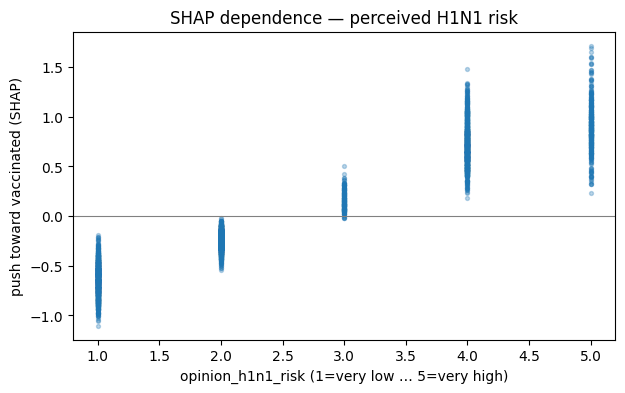

In [46]:
feat = 'opinion_h1n1_risk'; j = feat_names.index(feat)
plt.figure(figsize=(7,4)); plt.scatter(X_full[feat], shap[:, j], s=8, alpha=0.3); plt.axhline(0, c='grey', lw=0.8)
plt.title('SHAP dependence — perceived H1N1 risk')
plt.xlabel('opinion_h1n1_risk (1=very low … 5=very high)'); plt.ylabel('push toward vaccinated (SHAP)'); plt.show()

In [48]:
all_models = ['LogReg','RandomForest','HistGBM','LightGBM','Ensemble']
ranked = sorted(all_models, key=lambda n: -roc_auc_score(y, oof[n]))
summary = []
for i, n in enumerate(ranked, 1):
    fn = f'submission_{i}_{n.lower()}.csv'
    pd.DataFrame({ID: test[ID], TARGET: test_pred[n]}).to_csv(fn, index=False)
    summary.append({'rank': i, 'file': fn, 'model': n, 'CV ROC-AUC': round(roc_auc_score(y, oof[n]), 4)})
# best model is also saved as the primary submission.csv, format-checked against the sample
best = ranked[0]
submission = pd.DataFrame({ID: test[ID], TARGET: test_pred[best]}); submission.to_csv('submission.csv', index=False)

# Redefine 'sample' to match the expected submission file format for validation
sample = pd.DataFrame({ID: test[ID], TARGET: 0.5}) # Use dummy values for TARGET

assert list(submission.columns) == list(sample.columns) and len(submission) == len(sample)
assert (submission[ID].values == sample[ID].values).all()
assert submission[TARGET].between(0,1).all() and submission[TARGET].isna().sum() == 0
print('all files written & primary submission.csv format-checked  (best model: %s)' % best)
pd.DataFrame(summary)

all files written & primary submission.csv format-checked  (best model: Ensemble)


,rank,file,model,CV ROC-AUC
0,1,submission_1_ensemble.csv,Ensemble,0.8546
1,2,submission_2_histgbm.csv,HistGBM,0.8511
2,3,submission_3_lightgbm.csv,LightGBM,0.8510
3,4,submission_4_randomforest.csv,RandomForest,0.8252
4,5,submission_5_logreg.csv,LogReg,0.8221
